In [1]:
!pip install quantecon
!pip install numba
!pip install interpolation


[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: pip install --upgrade pip
^C
Traceback (most recent call last):
  File "/Users/hiroetomokana/code_box/learn/python/quant-macro-workshop/venv/bin/pip", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/Users/hiroetomokana/code_box/learn/python/quant-macro-workshop/venv/lib/python3.12/site-packages/pip/_internal/cli/main.py", line 79, in main
    return command.main(cmd_args)
           ^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/hiroetomokana/code_box/learn/python/quant-macro-workshop/venv/lib/python3.12/site-packages/pip/_internal/cli/base_command.py", line 101, in main
    return self._main(args)
           ^^^^^^^^^^^^^^^^
  File "/Users/hiroetomokana/code_box/learn/python/quant-macro-workshop/venv/lib/python3.12/site-packages/pip/_internal/cli/base_command.py", line 236, in _main
    self.handle_pip_version_check(options)
  File "/Users/hiroetomokana/code_box/learn/python/quant-macro-wor

In [1]:
import numpy as np
from quantecon.optimize import brentq
from quantecon.markov import rouwenhorst
from quantecon.markov import tauchen
from interpolation import interp
from numba import njit
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import scipy

# Aiyagari に従って...

In [2]:
# パラメータ
beta = 0.96
gamma = 3.0
rho = 0.6
sigma = 0.4
alpha = 0.36
delta = 0.08
b = 3.0

In [3]:
 (1 / beta) - 1

0.04166666666666674

In [4]:
r0 = 0.03
K0d = ((r0 + delta) / alpha) ** (1 / (alpha - 1))
w0 = (1 - alpha) * (K0d ** alpha)
print(w0)

1.246857279797728


In [5]:
from numba import njit

@njit
def maliar_grid(a_min, a_max, N, theta):
		a_grid = np.empty(N)
		for i in range(1,N+1):
				a_grid[i-1] = a_min + (a_max - a_min)*((i-1)/(N-1))**theta

		return a_grid

## 政策関数...

In [6]:
# 解く問題の設定を行う（パラメータ, グリッド, 効用関数や生産関数）
# モデルを変更する場合にはここを修正
class Setting:

    def __init__(self,
                 R=1.01,                          # 粗実質利子率
                 beta=0.99,                          # 割引因子
                 gamma=1,                          # 相対的リスク回避度(異時点間の代替弾力性の逆数)
                 b=0,                             # 内生的な状態変数の最小値, 借入制約
                 a_max=16,                        # 内生的な状態変数の最大値
                 na=21,                           # 内生的な状態変数のグリッド数
                 mu=0,                            # 外生変数のAR(1)過程の定数項
                 rho=0.6,                        # 外生変数のAR(1)過程の慣性
                 sigma=0.4,                       # 外生変数のAR(1)過程のショック項の標準偏差
                 nz = 11,                         # 外生変数のグリッド数
                 w = 0,                         # 賃金
                 lambdaPF = 1):                 # 政策関数の更新度

        # パラメータを設定する
        self.R = R
        self.beta = beta
        self.b = b
        self.gamma = gamma

        # 外生変数の遷移確率とグリッドを設定する
        # mc = rouwenhorst(nz, rho, sigma, mu)
        mc = tauchen(nz, rho, sigma, mu, n_std = 2.0)
        self.Pz = mc.P
        self.z_grid = np.exp(mc.state_values)

        # 内生的な状態変数のグリッドを設定する
        # a_grid = np.linspace(-b, a_max, na)
        # self.a_grid = a_grid

        a_grid = maliar_grid(-b,a_max,na, theta = 2.0)
        self.a_grid = a_grid

        # 賃金を設定
        self.w = w

        # 政策関数の更新度を設定する
        self.lambdaPF = lambdaPF

        # CRRA型効用関数と限界効用を定義する
        gamma = self.gamma
        if gamma == 1:
            self.utility = np.log
            self.mutility = njit(lambda x: 1 / x)
        else:
            self.utility = njit(lambda x: x**(1-gamma) / (1 - gamma))
            self.mutility = njit(lambda x: x**(-gamma))


		    # 政策関数の初期値を定義する
        z_grid = self.z_grid
        hfun_old = np.empty((len(a_grid), len(z_grid)))
        for i_a, a in enumerate(a_grid):
            for i_z, z in enumerate(z_grid):
                c_max = 0.5* (R * a + z + b)
                hfun_old[i_a, i_z] = c_max
        self.hfun_old = hfun_old


# 特定のアルゴリズムを実行して政策関数を更新する関数を出力する
# FOCを変更する場合やアルゴリズムを変更する場合はここを修正

# 今期の状態変数について繰り返し記号はi, 来期の状態変数について繰り返し記号はj

def TimeIteration(hp): # hpはSettingクラスからつくられるインスタンス

    # インスタンスからローカル変数を定義する
    R, beta, b, mutility, w = hp.R, hp.beta, hp.b, hp.mutility, hp.w
    a_grid, z_grid, Pz = hp.a_grid, hp.z_grid, hp.Pz

    @njit
    def FOCs(c, a, z, i_z, hfun):

        # 制約式から次期の内生的な状態変数を計算する
        aprime = R * a + w*z - c

        expectation = 0
        for j_z in range(len(z_grid)):
            # 政策関数の候補を補間して次期の制御変数を計算する
            cprime = interp(a_grid, hfun[:, j_z], aprime)

            # オイラー方程式の右辺を計算する
            expectation += mutility(cprime) * Pz[i_z, j_z]

        rhs = max(R * beta * expectation, mutility(R * a + w*z + b))

        FOC_diff = mutility(c) - rhs

        return FOC_diff


    @njit
    def UpdatePF(h_old):

        h_new = np.empty_like(h_old)
        for i_a in range(len(a_grid)):
            a = a_grid[i_a]
            for i_z in range(len(z_grid)):
                z = z_grid[i_z]
                c_star = brentq(FOCs, 1e-8, R * a + w*z + b, args=(a, z, i_z, h_old)).root
                h_new[i_a, i_z] = c_star

        return h_new

    return UpdatePF





# メイン関数：特定のアルゴリズムでiterationを行い、問題を解く関数
# 基本的には変更する必要がない

def SolveProblem(hp,               # Settingクラスからつくられるインスタンス
                Algorithm,         # アルゴリズムを指定
                tol=1e-4,          # 許容繰り返し誤差
                max_iter=10000,     # iteration回数の最大値
                verbose=True,      # 進捗を表示するかどうか
                print_skip=25):    # 進捗を何回ごとに表示するか


    # インスタンスからローカル変数を定義する
    R, beta, b, mutility = hp.R, hp.beta, hp.b, hp.mutility
    a_grid, z_grid, Pz = hp.a_grid, hp.z_grid, hp.Pz
    lambdaPF = hp.lambdaPF
    hfun_old = hp.hfun_old

    # チェックのために外生変数のグリッドと遷移確率を表示する
    # print(f"About exogenous variables:")
    # print(f"grid is {z_grid}.")
    # print(f"Transition matrix is {Pz}.")



    # 政策関数を更新する関数を取得する
    UpdatePF = Algorithm(hp)

    # iterationを行い、問題を解く
    i = 0
    error = tol + 1

    while i < max_iter and error > tol:

        # 政策関数を更新する
        hfun_new_tilde = UpdatePF(hfun_old)

        # 古い政策関数と加重平均する
        hfun_new = lambdaPF*hfun_new_tilde + (1-lambdaPF)*hfun_old

        error = np.max(np.abs(hfun_new-hfun_old))
        i += 1
        if verbose and i % print_skip == 0:      # 進捗をprint_skip回ごとに表示する
            print(f"Error at iteration {i} is {error}.")
        hfun_old = hfun_new

    if i == max_iter:
        print("Failed to converge!")

    if verbose and i < max_iter:
        print(f"\nConverged in {i} iterations.")

    return hfun_new

In [7]:
import time
start = time.time()
hp = Setting(beta=beta, gamma = gamma, b = b, lambdaPF = 1, na = 300, nz = 7, rho = rho, sigma = sigma, R = 1 + r0, w = w0)
hfun_c = SolveProblem(hp,TimeIteration)
end = time.time()

print(end- start)

Error at iteration 25 is 0.028056957033996355.
Error at iteration 50 is 0.0049119689182530735.
Error at iteration 75 is 0.0012549509085815203.
Error at iteration 100 is 0.0003573672965824226.
Error at iteration 125 is 0.00010359060295495048.

Converged in 126 iterations.
3.933351993560791


In [8]:
import time

In [9]:
start = time.time()
Amesh, Zmesh = np.meshgrid(hp.a_grid, hp.z_grid, indexing='ij')
hfun_a = Amesh * hp.R + hp.w * Zmesh - hfun_c
end = time.time()
print(end - start)

0.0005278587341308594


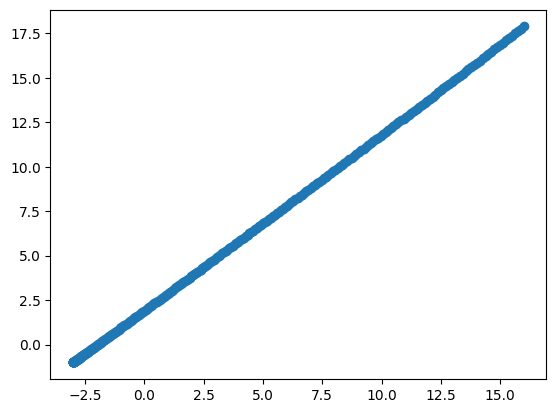

In [10]:
# hp.a_grid と hfun_a[0]のデータフレームを作る
df = pd.DataFrame({
    'x_axis': hp.a_grid,
    'y_axis': hfun_a[:, -1]})
# plot
plt.plot('x_axis', 'y_axis', data=df, linestyle='-', marker='o')

## 定常分布...

In [11]:
import numpy as np
from typing import Callable

# TODO: 定常分布が政策関数と同じ要素数であることを前提としてしまっている

# 政策関数によって得られたグリッド外の値が、グリッド上に移動する確率行列を計算する関数
@njit
def split_prob_to_agrid(aprime: float, agrid: np.ndarray) -> np.ndarray:
    """ 政策関数によって得られた a の値が、a_grid のどの点に移動するのかを示す確率ベクトルを計算する関数

    Args:
    aprime: 政策関数によって得られた a の値
    agrid: a のグリッド
    return: aprime が agrid のどの点に移動するのかを示す確率ベクトル
    """
    probs = np.zeros(len(agrid))
    # a の値が a_grid の最小値より小さい場合
    if aprime <= agrid[0]:
        probs[0] = 1.0
        return probs

    # a の値が a_grid の最大値より大きい場合
    if aprime >= agrid[-1]:
        probs[-1] = 1.0
        return probs

    # a の値が a_grid の最小値より大きく最大値より小さい場合
    for i in range(len(agrid)-1):
        if agrid[i] <= aprime <= agrid[i+1]:
            probs[i] = (agrid[i+1] - aprime) / (agrid[i+1] - agrid[i])
            probs[i+1] = (aprime - agrid[i]) / (agrid[i+1] - agrid[i])
            return probs

    # この行までに return されていない場合はエラーを出す
    raise ValueError("Splitting probability failed.")

@njit
def calc_weight_matrix(aprime_grid: np.ndarray, agrid: np.ndarray, split_prob_to_agrid = split_prob_to_agrid) -> np.ndarray:
    """ 前期の定常分布に係る重みづけ確率行列 weight_matrix を計算する関数

    Args:
        aprime_grid: 政策関数の行き先のグリッド
        agrid: 資産のグリッド
        split_prob: 政策関数によって得られた a の値が、a_grid のどの点に移動するのかを示す確率ベクトルを計算する関数

    Returns:
        weight_matrix: 前期の定常分布に係る重みづけ確率のグリッド、shape は aprime_grid と同じ
    """
    weight_matrix = np.empty((len(aprime_grid), len(aprime_grid[0]), len(agrid)))

    # aprime_grid は 二次元配列
    for i in range(len(aprime_grid)):
        for j in range(len(aprime_grid[0])):
            weight_matrix[i, j] = split_prob_to_agrid(float(aprime_grid[i, j]), agrid)
    return weight_matrix

@njit
def gen_pmesh(aprime_grid: np.ndarray, P: np.ndarray, next_y_index: int) -> np.ndarray:
    """ 遷移確率を 政策関数 aprime_grid との要素ごとの計算に使えるように meshgrid を生成する関数

    Args:
        aprime_grid (np.ndarray): 政策関数のグリッド
        P (np.ndarray): 遷移確率行列
        next_y_index (int): 次期の所得状態 y' のインデックス

    Returns:
        np.ndarray: 政策関数と遷移確率行列を使って計算するための meshgrid
    """
    pmesh = np.zeros(aprime_grid.shape)
    for i in range(len(aprime_grid)):
        for j in range(len(aprime_grid[0])):
            pmesh[i, j] = P[j, next_y_index]
    return pmesh

# def calc_sd_point(Pmesh, weight, sd_old) -> float:
#     """ 定常分布の一点を計算する関数

#     Args:
#         Pmesh (np.ndarray): 政策関数と遷移確率行列を使って計算した meshgrid
#         weight (np.ndarray): 前期の定常分布に係る重みづけ確率
#         sd_old (np.ndarray): 一期前の定常分布 f(a, y)

#     Returns:
#         float: 更新された(次期の)定常分布の一点の値
#     """
#     return np.sum(Pmesh * weight * sd_old)

@njit
def update_sd(aprime_grid: np.ndarray, agrid: np.ndarray, sd_old: np.ndarray, P: np.ndarray,
            split_prob_to_agrid = split_prob_to_agrid, calc_weight_matrix = calc_weight_matrix,
            gen_P = gen_pmesh,
            # calc_sd_point = calc_sd_point
            ) -> np.ndarray:
    """ 定常分布を更新する関数

    Args:
        aprime_grid (np.ndarray): 政策関数のグリッド
        agrid (np.ndarray): 資産のグリッド
        sd_old (np.ndarray): 更新前の定常分布
        P (np.ndarray): 遷移確率行列
        split_prob (Callable): 政策関数によって得られた a の値が、a_grid のどの点に移動するのかを示す確率ベクトルを計算する関数
        calc_weight (Callable): 前期の定常分布に係る重みづけ確率 weight を計算する関数
        gen_P (Callable): 遷移確率を 政策関数 aprime_grid との要素ごとの計算に使えるように meshgrid を生成する関数
        calc_sd_point (Callable): 定常分布の一点を計算する関数

    Returns:
        sd_new（np.ndarray）: 更新された定常分布のグリッド
    """
    sd_new = np.zeros(sd_old.shape)
    weight_matrix = calc_weight_matrix(aprime_grid, agrid, split_prob_to_agrid)
    for i in range(len(aprime_grid)):
        for j in range(len(aprime_grid[0])):
            p_mesh = gen_P(aprime_grid, P, j)
            # sd_new[i, j] = calc_sd_point(p_mesh, weight_matrix[:,:,i], sd_old)
            sd_new[i,j] = np.sum(p_mesh * weight_matrix[:,:,i] * sd_old)

    return sd_new

@njit
def sd_iteration(sd0: np.ndarray, aprime_grid: np.ndarray, agrid: np.ndarray, P: np.ndarray,
                        tol: float = 1e-6, max_iter: int = 1000,
                        update_sd = update_sd) -> np.ndarray:
    """ 定常分布を計算する関数

    Args:
        aprime_grid (np.ndarray): 政策関数のグリッド
        agrid (np.ndarray): 資産のグリッド
        guess_sd (np.ndarray): 初期の定常分布のグリッド
        P (np.ndarray): 遷移確率行列
        tol (float, optional): 許容する誤差. Defaults to 1e-6.
        max_iter (int, optional): 最大の反復回数. Defaults to 1000.
        update_sd (_type_, optional): 定常分布を更新する関数. Defaults to update_sd.

    Returns:
        np.ndarray: 収束した定常分布のグリッド
    """
    sd_old = sd0

    diff = tol + 1
    iteration = 0
    while diff > tol and iteration < max_iter:
        sd_new = update_sd(aprime_grid, agrid, sd_old, P)
        diff = np.max(np.abs(sd_new - sd_old))
        sd_old = sd_new
        iteration += 1
        # print(f"Iteration {iteration}: diff = {diff}")

    # 最終イタレーション回数の出力
    print(f"Total iterations until convergence: {iteration}")

    # 定常分布の出力
    # print("Stationary distribution f_{i,j}:")
    # print(sd_new)
    return sd_new


In [12]:
# hfun_c から 時期のアセット aの政策関数を求める
hfun_aprime = np.empty((len(hp.a_grid), len(hp.z_grid)))
a_mesh, z_mesh = np.meshgrid(hp.a_grid, hp.z_grid, indexing='ij') # ユニバーサル関数を使用するためのグリッドを生成
hfun_aprime = hp.R * a_mesh + hp.w * z_mesh - hfun_c

# 初期の定常分布を定義
sd_grid = np.full(hfun_aprime.shape, 1/hfun_aprime.size)

## 実際に反復

In [13]:
(1- 0.96) / 0.96 - 0.001

0.040666666666666705

In [ ]:


r0s = np.linspace(0, 0.04, 20)

diff = 1
loop = 0
while abs(diff) > 1e-10:
# for i in range(20):
    loop += 1
    # r0 = r0s[i]
    print("loop: ", loop)
    # 1
    K0d = ((r0 + delta) / alpha) ** (1 / (alpha - 1))
    w0 = (1 - alpha) * (K0d ** alpha)

    # 2
    hp = Setting(beta=beta, gamma = gamma, b = b, lambdaPF = 1, na = 300, nz = 7, rho = rho, sigma = sigma, R = 1 + r0, w = w0)
    hfun_c = SolveProblem(hp,TimeIteration)

    # 3
    # hfun_c から 時期のアセット aの政策関数を求める
    hfun_aprime = np.empty((len(hp.a_grid), len(hp.z_grid)))
    a_mesh, z_mesh = np.meshgrid(hp.a_grid, hp.z_grid, indexing='ij') # ユニバーサル関数を使用するためのグリッドを生成
    hfun_aprime = hp.R * a_mesh + hp.w * z_mesh - hfun_c
    hfun_aprime_interp = hfun_aprime

    # aprimeの政策関数を補間
    # a_grid_sd = np.linspace(-hp.b, hp.a_grid[-1] + 30, len(hp.a_grid) + 60)
    # hfun_aprime_interp = np.empty((len(a_grid_sd), len(hp.z_grid)))
    # for i in range(hp.z_grid.size):
    #   hfun = scipy.interpolate.interp1d(hp.a_grid, hfun_aprime[:, i], fill_value="extrapolate")
    #   for j in range(len(a_grid_sd)):
    #     hfun_aprime_interp[j, i] = hfun(a_grid_sd[j])
      # hfun_aprime_interp[:, i] = interp(hp.a_grid, hfun_aprime[:, i], a_grid_sd)

    # 初期の定常分布を定義
    sd_grid = np.full(hfun_aprime_interp.shape, 1/hfun_aprime_interp.size)

    # sd = sd_iteration(sd_grid, hfun_aprime_interp, a_grid_sd, hp.Pz)
    sd = sd_iteration(sd_grid, hfun_aprime_interp, hp.a_grid, hp.Pz)

    # 4
    # Amesh, _ = np.meshgrid(a_grid_sd, hp.z_grid, indexing='ij')
    Amesh, _ = np.meshgrid(hp.a_grid, hp.z_grid, indexing='ij')
    A0 = np.sum(Amesh * sd)
    print("A0: ", A0)
    diff = (A0 - K0d)
    print("diff: ", diff)

    r0 = r0 - 0.001 * diff

r0 = r0 + 0.001 * diff

loop:  1
Error at iteration 25 is 0.028056957033996355.
Error at iteration 50 is 0.0049119689182530735.
Error at iteration 75 is 0.0012549509085815203.
Error at iteration 100 is 0.0003573672965824226.
Error at iteration 125 is 0.00010359060295495048.

Converged in 126 iterations.
Total iterations until convergence: 191
A0:  5.994045375789144
diff:  -0.38192935044923715
loop:  2
Error at iteration 25 is 0.028133015595844135.
Error at iteration 50 is 0.004982906550158983.
Error at iteration 75 is 0.0012992550469734798.
Error at iteration 100 is 0.00037839202739342603.
Error at iteration 125 is 0.00011261007419038904.

Converged in 128 iterations.
Total iterations until convergence: 199
A0:  6.150340064486849
diff:  -0.19119739970342842
loop:  3
Error at iteration 25 is 0.028170720068117383.
Error at iteration 50 is 0.005018313415612319.
Error at iteration 75 is 0.001321287080761957.
Error at iteration 100 is 0.00038926910087955235.
Error at iteration 125 is 0.00011767119230632339.

Conve

Exception ignored on calling ctypes callback function: <function ExecutionEngine._raw_object_cache_notify at 0x1080a6b60>
Traceback (most recent call last):
  File "/Users/hiroetomokana/code_box/learn/python/quant-macro-workshop/venv/lib/python3.12/site-packages/llvmlite/binding/executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):

KeyboardInterrupt: 


Error at iteration 25 is 0.028206540967958826.
Error at iteration 50 is 0.00505211487555135.
Error at iteration 75 is 0.0013424485327697688.
Error at iteration 100 is 0.00039996196711156173.
Error at iteration 125 is 0.00012266683904038622.

Converged in 130 iterations.
Total iterations until convergence: 206
A0:  6.308107250593421
diff:  -3.077130106277082e-08
loop:  25
Error at iteration 25 is 0.028206540973966465.
Error at iteration 50 is 0.00505211488124635.
Error at iteration 75 is 0.0013424485363404681.
Error at iteration 100 is 0.0003999619690513434.
Error at iteration 125 is 0.0001226668398870423.

Converged in 130 iterations.
Total iterations until convergence: 206
A0:  6.308107263460188
diff:  -1.5166127909083116e-08
loop:  26
Error at iteration 25 is 0.02820654097694053.
Error at iteration 50 is 0.00505211488405477.
Error at iteration 75 is 0.0013424485381048346.
Error at iteration 100 is 0.0003999619700070234.


In [ ]:
# 定常分布 sd のプロット
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# メッシュグリッドを作成
X, Y = np.meshgrid(a_grid_sd, hp.z_grid)
Z = sd.T  # データの形状を合わせるため転置（必要なら）

# 3Dプロット
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

# 軸ラベル
ax.set_xlabel('hp.a_grid (X-axis)')
ax.set_ylabel('hp.z_grid (Y-axis)')
ax.set_zlabel('sd (Z-axis)')
ax.set_title('3D Surface Plot of sd')

plt.show()

In [ ]:
hp.z_grid

In [ ]:
r0 # 均衡時の金利

0.02435491637376564

In [ ]:
K0d # 均衡時の資本

6.923030241508172

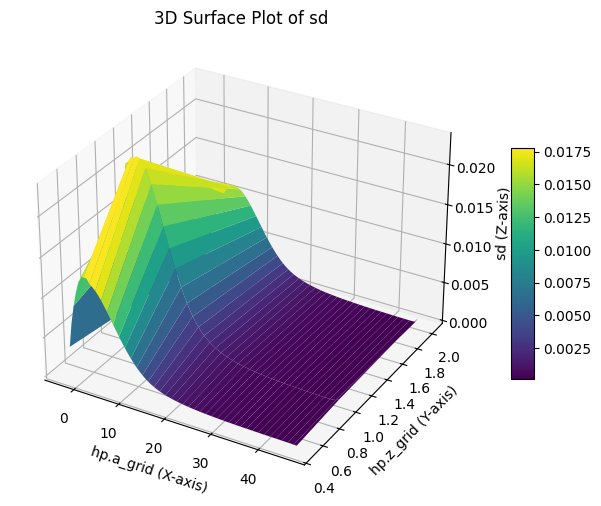

In [ ]:
# 定常分布 sd のプロット
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# メッシュグリッドを作成
X, Y = np.meshgrid(a_grid_sd, hp.z_grid)
Z = sd.T  # データの形状を合わせるため転置（必要なら）

# 3Dプロット
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

# 軸ラベル
ax.set_xlabel('hp.a_grid (X-axis)')
ax.set_ylabel('hp.z_grid (Y-axis)')
ax.set_zlabel('sd (Z-axis)')
ax.set_title('3D Surface Plot of sd')

plt.show()

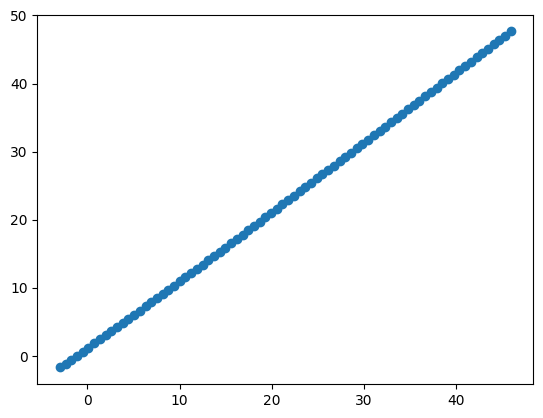

In [ ]:
# hp.a_grid と hfun_a[0]のデータフレームを作る
df = pd.DataFrame({
    'x_axis': a_grid_sd,
    'y_axis': hfun_aprime_interp[:, -1]})
# plot
plt.plot('x_axis', 'y_axis', data=df, linestyle='-', marker='o')

In [ ]:
# asset grid: Value function
Kmin = -3               # lower bound asset grid over value function
Kmax = 20             # upper bound
nK = 10000                 # number of equispaced points
K =  np.linspace(Kmin, Kmax, nK)   # asset grid

L = 1

In [ ]:
r = alpha * K ** (alpha - 1) * L ** (1 - alpha) - delta

<ipython-input-49-01e6ba3c5f84>:1: RuntimeWarning: invalid value encountered in power
  r = alpha * K ** (alpha - 1) * L ** (1 - alpha) - delta


In [ ]:
delta

0.08

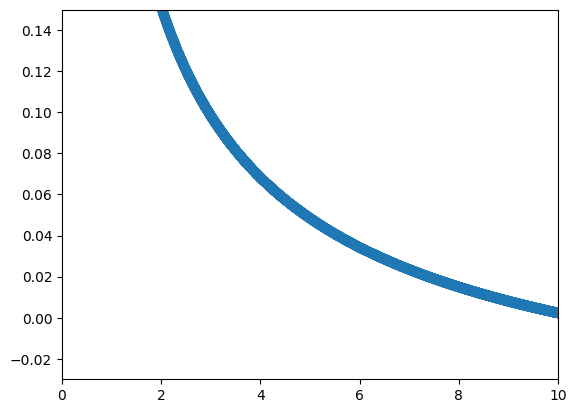

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# データフレームの作成
df = pd.DataFrame({
    'x_axis': K,
    'y_axis': r,
})

# プロット
plt.plot('x_axis', 'y_axis', data=df, linestyle='-', marker='o')

# 縦軸の範囲設定
plt.ylim(-0.03, 0.15)
plt.xlim(0, 10)

# グラフの表示
plt.show()


In [ ]:



# 前提として、必要な関数とクラスが定義されているものとします


# パラメータの設定
rmin = -0.035                # lower bound asset grid over value function
rmax = 0.035                # upper bound
r1_points = 125              # number of points in the range from -0.03 to 0.02
r2_points = 375             # number of points in the range from 0.02 to 0.035

# -0.03 to 0.02 and 0.02 to 0.035分のグリッド点を設定
r_test1 = np.linspace(rmin, 0.015, r1_points)
r_test2 = np.linspace(0.015, rmax, r2_points)

# 両方のグリッドを結合して一つのグリッドに
r_test = np.concatenate((r_test1, r_test2))

# A0を格納するリスト
A0_list = []

for r0 in r_test:
    # ステップ1: K0dとw0の計算
    K0d = ((r0 + delta) / alpha) ** (1 / (alpha - 1))
    w0 = (1 - alpha) * (K0d ** alpha)

    # ステップ2: hpとhfun_cの設定
    hp = Setting(beta=beta, gamma=gamma, b=b, lambdaPF=1, na=20, nz=3, rho=rho, sigma=sigma, R=1 + r0, w=w0)
    hfun_c = SolveProblem(hp, TimeIteration)

    # ステップ3: hfun_aprimeの計算と補間
    a_mesh, z_mesh = np.meshgrid(hp.a_grid, hp.z_grid, indexing='ij')
    hfun_aprime = hp.R * a_mesh + hp.w * z_mesh - hfun_c

    a_grid_sd = np.linspace(-hp.b, hp.a_grid[-1] + 30, len(hp.a_grid) + 60)
    hfun_aprime_interp = np.empty((len(a_grid_sd), len(hp.z_grid)))
    for i in range(hp.z_grid.size):
        hfun = scipy.interpolate.interp1d(hp.a_grid, hfun_aprime[:, i], fill_value="extrapolate")
        hfun_aprime_interp[:, i] = hfun(a_grid_sd)

    # 定常分布の計算
    sd_grid = np.full(hfun_aprime_interp.shape, 1 / hfun_aprime_interp.size)
    sd = sd_iteration(sd_grid, hfun_aprime_interp, a_grid_sd, hp.Pz)

    # ステップ4: A0の計算
    Amesh, _ = np.meshgrid(a_grid_sd, hp.z_grid, indexing='ij')
    A0 = np.sum(Amesh * sd)
    A0_list.append(A0)

# 結果の表示
print("計算されたA0のリスト:", A0_list)


<ipython-input-59-801839f15377>:26: UserWarning: The API of rouwenhorst has changed from `rouwenhorst(n, ybar, sigma, rho)` to `rouwenhorst(n, rho, sigma, mu=0.)`. To find more details please visit: https://github.com/QuantEcon/QuantEcon.py/issues/663.
  mc = rouwenhorst(nz, rho, sigma, mu)


Error at iteration 25 is 0.004249231283391275.
Error at iteration 50 is 0.0001202845345336101.

Converged in 51 iterations.
Total iterations until convergence: 79


<ipython-input-59-801839f15377>:26: UserWarning: The API of rouwenhorst has changed from `rouwenhorst(n, ybar, sigma, rho)` to `rouwenhorst(n, rho, sigma, mu=0.)`. To find more details please visit: https://github.com/QuantEcon/QuantEcon.py/issues/663.
  mc = rouwenhorst(nz, rho, sigma, mu)


Error at iteration 25 is 0.0041126514739819875.
Error at iteration 50 is 0.00012123346194758966.

Converged in 52 iterations.
Total iterations until convergence: 79


<ipython-input-59-801839f15377>:26: UserWarning: The API of rouwenhorst has changed from `rouwenhorst(n, ybar, sigma, rho)` to `rouwenhorst(n, rho, sigma, mu=0.)`. To find more details please visit: https://github.com/QuantEcon/QuantEcon.py/issues/663.
  mc = rouwenhorst(nz, rho, sigma, mu)


...

Error at iteration 25 is 0.029150216586868893.
Error at iteration 50 is 0.0057190258831010254.
Error at iteration 75 is 0.00190337994743639.
Error at iteration 100 is 0.0007577933724494113.
Error at iteration 125 is 0.0003239962371399674.
Error at iteration 150 is 0.00014293782605023786.

Converged in 162 iterations.
Total iterations until convergence: 1000


<ipython-input-59-801839f15377>:26: UserWarning: The API of rouwenhorst has changed from `rouwenhorst(n, ybar, sigma, rho)` to `rouwenhorst(n, rho, sigma, mu=0.)`. To find more details please visit: https://github.com/QuantEcon/QuantEcon.py/issues/663.
  mc = rouwenhorst(nz, rho, sigma, mu)


Error at iteration 25 is 0.02915987957628019.
Error at iteration 50 is 0.005728000899480223.
Error at iteration 75 is 0.001910571862545618.
Error at iteration 100 is 0.0007628475860868011.
Error at iteration 125 is 0.00032725800443489383.
Error at iteration 150 is 0.0001449146662151346.

Converged in 162 iterations.
Total iterations until convergence: 1000


<ipython-input-59-801839f15377>:26: UserWarning: The API of rouwenhorst has changed from `rouwenhorst(n, ybar, sigma, rho)` to `rouwenhorst(n, rho, sigma, mu=0.)`. To find more details please visit: https://github.com/QuantEcon/QuantEcon.py/issues/663.
  mc = rouwenhorst(nz, rho, sigma, mu)


Error at iteration 25 is 0.029169533630439837.
Error at iteration 50 is 0.005736977118848685.
Error at iteration 75 is 0.0019177805630439249.
Error at iteration 100 is 0.0007679300139504797.
Error at iteration 125 is 0.0003305504442208118.
Error at iteration 150 is 0.00014691832490321133.

Converged in 163 iterations.
Total iterations until convergence: 1000
計算されたA0のリスト: [0.9308203984753898, 0.9318650629654965, 0.9331673127853727, 0.934750924256551, 0.9365806639939668, 0.9385982567073787, 0.9408857067722881, 0.9433689548657598, 0.9461230320843944, 0.9490648133785511, 0.9522795317453284, 0.9557164248404747, 0.9593304904752649, 0.9632068692198673, 0.9672577019421309, 0.9715701963367951, 0.9760642675041122, 0.9808576157774296, 0.9858251539367962, 0.9910522062397098, 0.996451584243423, 1.0022458735797772, 1.0083634158960804, 1.0147435685790613, 1.0212980391531774, 1.0281227827436412, 1.0351272895026107, 1.042396774272276, 1.0498418708693964, 1.0576318149390698, 1.0655345763411468, 1.073661

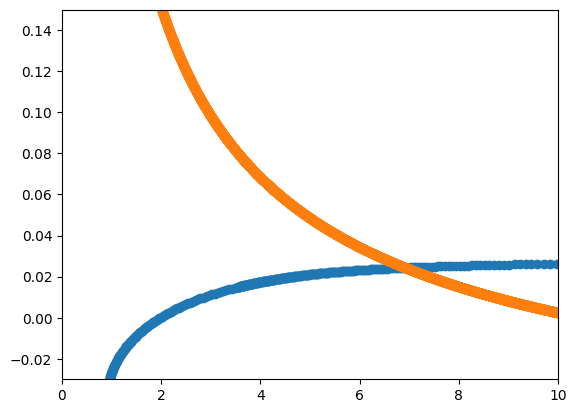

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# データフレームの作成
df1 = pd.DataFrame({
    'x_axis': A0_list,
    'y_axis': r_test,
})

df2 = pd.DataFrame({
    'x_axis': K,
    'y_axis': r,
})

# プロット
plt.plot('x_axis', 'y_axis', data=df1, linestyle='-', marker='o')
plt.plot('x_axis', 'y_axis', data=df2, linestyle='-', marker='o')
# 縦軸の範囲設定
plt.ylim(-0.03, 0.15)
plt.xlim(0, 10)


# グラフの表示
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21033 (\N{CJK UNIFIED IDEOGRAPH-5229}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36039 (\N{CJK UNIFIED IDEOGRAPH-8CC7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas

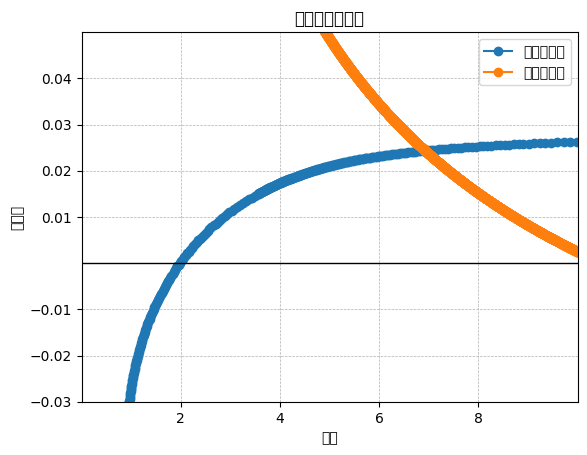

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 日本語フォントの設定
!apt-get -qq install fonts-ipafont-gothic  # IPAフォントをインストール
plt.rcParams['font.family'] = 'IPAGothic'  # フォントを設定

# 以下にグラフのコードを続けます



# データフレームの作成
df1 = pd.DataFrame({
    'x_axis': A0_list,
    'y_axis': r_test,
})

df2 = pd.DataFrame({
    'x_axis': K,
    'y_axis': r,
})

# プロット
plt.plot('x_axis', 'y_axis', data=df1, linestyle='-', marker='o', label='総資本需要')
plt.plot('x_axis', 'y_axis', data=df2, linestyle='-', marker='o', label='総資本供給')

# 軸のタイトル設定
plt.xlabel('資本')
plt.ylabel('利子率')

# 図のタイトル設定
plt.title('資本市場の均衡')

# 凡例の表示
plt.legend()

# 縦軸の範囲設定
plt.ylim(-0.03, 0.05)
plt.xlim(0, 10)

# グリッド線の追加
plt.axhline(0, color='black', linewidth=1)  # y=0 の黒い線
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks([2, 4, 6, 8])
plt.yticks([-0.03, -0.02, -0.01, 0.01, 0.02, 0.03, 0.04])

# グラフの表示
plt.show()

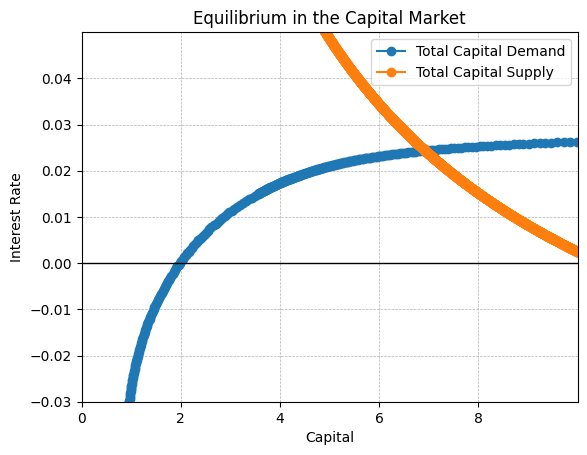

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframes
df1 = pd.DataFrame({
    'x_axis': A0_list,
    'y_axis': r_test,
})

df2 = pd.DataFrame({
    'x_axis': K,
    'y_axis': r,
})

# Plotting
plt.plot('x_axis', 'y_axis', data=df1, linestyle='-', marker='o', label='Total Capital Demand')
plt.plot('x_axis', 'y_axis', data=df2, linestyle='-', marker='o', label='Total Capital Supply')

# Set axis labels
plt.xlabel('Capital')
plt.ylabel('Interest Rate')

# Set title
plt.title('Equilibrium in the Capital Market')

# Show legend
plt.legend()

# Set axis ranges
plt.ylim(-0.03, 0.05)
plt.xlim(0, 10)

# Add grid lines
plt.axhline(0, color='black', linewidth=1)  # Black line at y=0
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks([0,2, 4, 6, 8])
plt.yticks([-0.03, -0.02, -0.01,0, 0.01, 0.02, 0.03, 0.04])

plt.savefig('capital_market_equilibrium.png', format='png')

# Show the plot
plt.show()


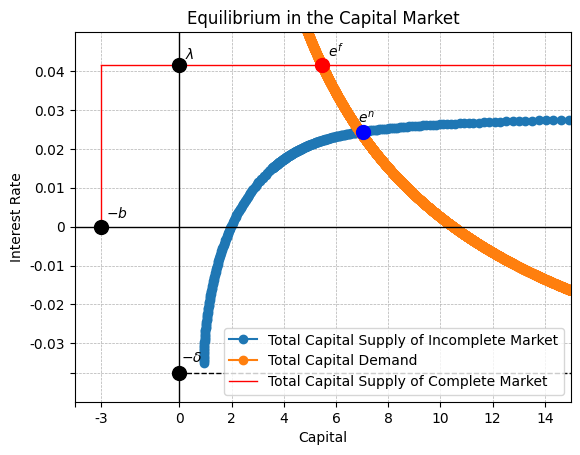

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframes
df1 = pd.DataFrame({
    'x_axis': A0_list,
    'y_axis': r_test,
})

df2 = pd.DataFrame({
    'x_axis': K,
    'y_axis': r,
})

# Plotting
plt.plot('x_axis', 'y_axis', data=df1, linestyle='-', marker='o', label='Total Capital Supply of Incomplete Market')
plt.plot('x_axis', 'y_axis', data=df2, linestyle='-', marker='o', label='Total Capital Demand')

# Add horizontal line for Incomplete Market Equilibrium from x=-3 to x=10
plt.plot([-3, 20], [0.04166666666666674, 0.04166666666666674], color='red', linestyle='-', linewidth=1, label='Total Capital Supply of Complete Market')

# Set axis labels
plt.xlabel('Capital')
plt.ylabel('Interest Rate')

# Set title
plt.title('Equilibrium in the Capital Market')

# Add vertical line at x=0 (Y-axis)
plt.axvline(x=0, color='black', linewidth=1)

# Add vertical dashed line at x=-3 from y=0 to y=0.04166666666666674
plt.plot([-3, -3], [0, 0.04166666666666674], color='red', linestyle='-', linewidth=1)

# Add grid lines
plt.axhline(0, color='black', linewidth=1)  # Black line at y=0
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize x-ticks and y-ticks
plt.xticks([-4, -3, 0, 2, 4, 6, 8, 10, 12, 14], labels=['', '-3', '0', '2', '4', '6', '8','10','12','14'])
plt.yticks([-0.0375, -0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03, 0.04], labels=['', '-0.03', '-0.02', '-0.01', '0', '0.01', '0.02', '0.03', '0.04'])

# Add the point at (0, 0.04166666666666674) with label 'λ'
plt.scatter(0, 0.04166666666666674, color='black', s=100, zorder=5)
plt.text(0.2, 0.0425, r'$\lambda$', fontsize=10, verticalalignment='bottom', horizontalalignment='left', zorder=6)

# Add the point at (7.023030241508172, 0.02435491637376564) with label 'e^n'
plt.scatter(7.023030241508172, 0.02435491637376564, color='blue', s=100, zorder=5)
plt.text(7.5, 0.026, r'$e^n$', fontsize=10, verticalalignment='bottom', horizontalalignment='right', zorder=6)

# Add the point at (5.4468073801132295, 0.04166666666666674) with label 'e^f'
plt.scatter(5.4468073801132295, 0.04166666666666674, color='red', s=100, zorder=5)
plt.text(5.7, 0.043, r'$e^f$', fontsize=10, verticalalignment='bottom', horizontalalignment='left', zorder=6)

# Add the point at (0, -0.0375) with label '-δ'
plt.scatter(0, -0.0375, color='black', s=100, zorder=5)
plt.text(0.05, -0.0355, r'$-\delta$', fontsize=10, verticalalignment='bottom', horizontalalignment='left', zorder=6)

# Add the point at (-3, 0) with label '-b'
plt.scatter(-3, 0, color='black', s=100, zorder=5)
plt.text(-2.8, 0.0015, r'$-b$', fontsize=10, verticalalignment='bottom', horizontalalignment='left', zorder=6)

# Add horizontal dashed line from (0, -0.0375) to (10, -0.0375)
plt.plot([0, 20], [-0.0375, -0.0375], color='black', linestyle='--', linewidth=1, zorder=5)

# Show legend
plt.legend()

# Set axis ranges
plt.ylim(-0.045, 0.05)
plt.xlim(-4, 15)

# Save the plot
plt.savefig('Capital_Market_Equilibrium.png', format='png')

# Show the plot
plt.show()




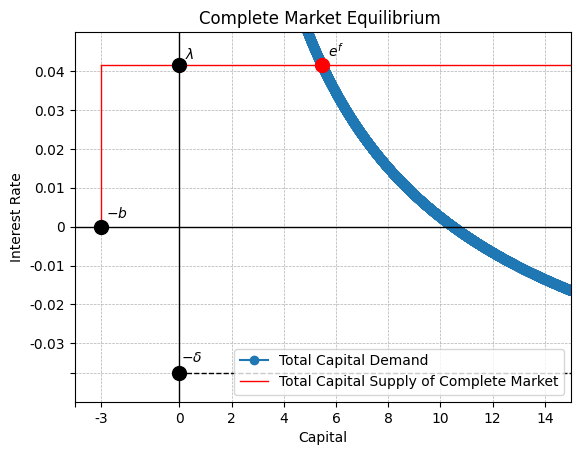

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframes
# df1 = pd.DataFrame({
#     'x_axis': A0_list,
#     'y_axis': r_test,
# })

df2 = pd.DataFrame({
    'x_axis': K,
    'y_axis': r,
})

# Plotting
# plt.plot('x_axis', 'y_axis', data=df1, linestyle='-', marker='o', label='Total Capital Supply of complete Market')
plt.plot('x_axis', 'y_axis', data=df2, linestyle='-', marker='o', label='Total Capital Demand')

# Add horizontal line for Incomplete Market Equilibrium from x=-3 to x=10
plt.plot([-3, 20], [0.04166666666666674, 0.04166666666666674], color='red', linestyle='-', linewidth=1, label='Total Capital Supply of Complete Market')

# Set axis labels
plt.xlabel('Capital')
plt.ylabel('Interest Rate')

# Set title
plt.title('Complete Market Equilibrium ')

# Add vertical line at x=0 (Y-axis)
plt.axvline(x=0, color='black', linewidth=1)

# Add vertical dashed line at x=-3 from y=0 to y=0.04166666666666674
plt.plot([-3, -3], [0, 0.04166666666666674], color='red', linestyle='-', linewidth=1)

# Add grid lines
plt.axhline(0, color='black', linewidth=1)  # Black line at y=0
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize x-ticks and y-ticks
plt.xticks([-4, -3, 0, 2, 4, 6, 8, 10, 12, 14], labels=['', '-3', '0', '2', '4', '6', '8','10','12','14'])
plt.yticks([-0.0375, -0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03, 0.04], labels=['', '-0.03', '-0.02', '-0.01', '0', '0.01', '0.02', '0.03', '0.04'])

# Add the point at (0, 0.04166666666666674) with label 'λ'
plt.scatter(0, 0.04166666666666674, color='black', s=100, zorder=5)
plt.text(0.2, 0.0425, r'$\lambda$', fontsize=10, verticalalignment='bottom', horizontalalignment='left', zorder=6)

# # Add the point at (7.023030241508172, 0.02435491637376564) with label 'e^n'
# plt.scatter(7.023030241508172, 0.02435491637376564, color='blue', s=100, zorder=5)
# plt.text(7.5, 0.026, r'$e^n$', fontsize=10, verticalalignment='bottom', horizontalalignment='right', zorder=6)

# Add the point at (5.4468073801132295, 0.04166666666666674) with label 'e^f'
plt.scatter(5.4468073801132295, 0.04166666666666674, color='red', s=100, zorder=5)
plt.text(5.7, 0.043, r'$e^f$', fontsize=10, verticalalignment='bottom', horizontalalignment='left', zorder=6)

# Add the point at (0, -0.0375) with label '-δ'
plt.scatter(0, -0.0375, color='black', s=100, zorder=5)
plt.text(0.05, -0.0355, r'$-\delta$', fontsize=10, verticalalignment='bottom', horizontalalignment='left', zorder=6)

# Add the point at (-3, 0) with label '-b'
plt.scatter(-3, 0, color='black', s=100, zorder=5)
plt.text(-2.8, 0.0015, r'$-b$', fontsize=10, verticalalignment='bottom', horizontalalignment='left', zorder=6)

# Add horizontal dashed line from (0, -0.0375) to (10, -0.0375)
plt.plot([0, 20], [-0.0375, -0.0375], color='black', linestyle='--', linewidth=1, zorder=5)

# Show legend
plt.legend()

# Set axis ranges
plt.ylim(-0.045, 0.05)
plt.xlim(-4, 15)

# Save the plot
plt.savefig('Complete_Market_Equilibrium.png', format='png')

# Show the plot
plt.show()




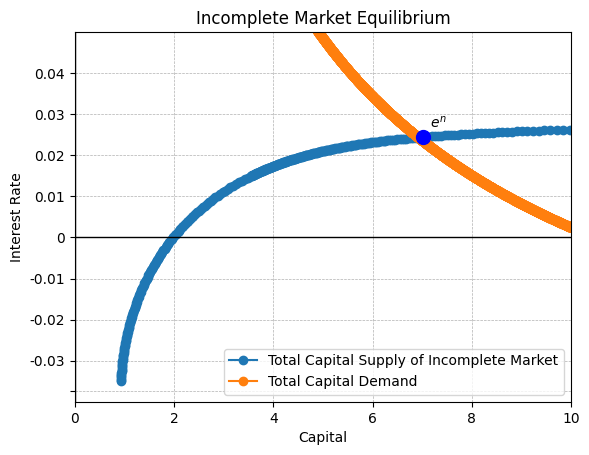

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframes
df1 = pd.DataFrame({
    'x_axis': A0_list,
    'y_axis': r_test,
})

df2 = pd.DataFrame({
    'x_axis': K,
    'y_axis': r,
})

# Plotting
plt.plot('x_axis', 'y_axis', data=df1, linestyle='-', marker='o', label='Total Capital Supply of Incomplete Market')
plt.plot('x_axis', 'y_axis', data=df2, linestyle='-', marker='o', label='Total Capital Demand')

# # Add horizontal line for Incomplete Market Equilibrium from x=-3 to x=10
# plt.plot([-3, 20], [0.04166666666666674, 0.04166666666666674], color='red', linestyle='-', linewidth=1, label='Total Capital Supply of incomplete Market')

# Set axis labels
plt.xlabel('Capital')
plt.ylabel('Interest Rate')

# Set title
plt.title('Incomplete Market Equilibrium')

# Add vertical line at x=0 (Y-axis)
plt.axvline(x=0, color='black', linewidth=1)

# # Add vertical dashed line at x=-3 from y=0 to y=0.04166666666666674
# plt.plot([-3, -3], [0, 0.04166666666666674], color='red', linestyle='-', linewidth=1)

# Add grid lines
plt.axhline(0, color='black', linewidth=1)  # Black line at y=0
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize x-ticks and y-ticks
plt.xticks([ 0, 2, 4, 6, 8, 10], labels=[ '0', '2', '4', '6', '8','10'])
plt.yticks([-0.0375, -0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03, 0.04], labels=['', '-0.03', '-0.02', '-0.01', '0', '0.01', '0.02', '0.03', '0.04'])

# # Add the point at (0, 0.04166666666666674) with label 'λ'
# plt.scatter(0, 0.04166666666666674, color='black', s=100, zorder=5)
# plt.text(0.2, 0.0425, r'$\lambda$', fontsize=10, verticalalignment='bottom', horizontalalignment='left', zorder=6)

# Add the point at (7.023030241508172, 0.02435491637376564) with label 'e^n'
plt.scatter(7.023030241508172, 0.02435491637376564, color='blue', s=100, zorder=5)
plt.text(7.5, 0.026, r'$e^n$', fontsize=10, verticalalignment='bottom', horizontalalignment='right', zorder=6)

# # Add the point at (5.4468073801132295, 0.04166666666666674) with label 'e^f'
# plt.scatter(5.4468073801132295, 0.04166666666666674, color='red', s=100, zorder=5)
# plt.text(5.7, 0.043, r'$e^f$', fontsize=10, verticalalignment='bottom', horizontalalignment='left', zorder=6)

# # Add the point at (0, -0.0375) with label '-δ'
# plt.scatter(0, -0.0375, color='black', s=100, zorder=5)
# plt.text(0.05, -0.0355, r'$-\delta$', fontsize=10, verticalalignment='bottom', horizontalalignment='left', zorder=6)

# # Add the point at (-3, 0) with label '-b'
# plt.scatter(-3, 0, color='black', s=100, zorder=5)
# plt.text(-2.8, 0.0015, r'$-b$', fontsize=10, verticalalignment='bottom', horizontalalignment='left', zorder=6)

# # Add horizontal dashed line from (0, -0.0375) to (10, -0.0375)
# plt.plot([0, 20], [-0.0375, -0.0375], color='black', linestyle='--', linewidth=1, zorder=5)

# Show legend
plt.legend()

# Set axis ranges
plt.ylim(-0.04, 0.05)
plt.xlim(0, 10)

# Save the plot
plt.savefig('Incomplete_Market_Equilibrium.png', format='png')

# Show the plot
plt.show()


